In [1]:
import numpy as np
from spender import SpectrumAutoencoder, SpeculatorActivation
from spender.data.hetdex import HETDEX


data_dir = '/home/qezlou/projects/lae_detection/data/'
instrument = HETDEX()

trainloader = instrument.get_data_loader(data_dir, which="train", batch_size=1024)

for k, batch in enumerate(trainloader):
    batch_size = len(batch[0])
    spec, w, z = batch
    assert np.all(~np.isnan(w.numpy())), "w contains NaN values"
    assert not np.any(np.isnan(w.numpy()))
    print(f"Batch {k}: spec shape {spec.shape}, w shape {w.shape}, z shape {z.shape}")

/home/qezlou/projects/lae_detection/spender/spender/data/hetdex.py:100: RuntimeWarning: divide by zero encountered in divide
  ivar = torch.from_numpy(1/f['calfibe'][:]**2)


Batch 0: spec shape torch.Size([1024, 1036]), w shape torch.Size([1024, 1036]), z shape torch.Size([1024])
Batch 1: spec shape torch.Size([1024, 1036]), w shape torch.Size([1024, 1036]), z shape torch.Size([1024])
Batch 2: spec shape torch.Size([1024, 1036]), w shape torch.Size([1024, 1036]), z shape torch.Size([1024])
Batch 3: spec shape torch.Size([1024, 1036]), w shape torch.Size([1024, 1036]), z shape torch.Size([1024])
Batch 4: spec shape torch.Size([1024, 1036]), w shape torch.Size([1024, 1036]), z shape torch.Size([1024])
Batch 5: spec shape torch.Size([1024, 1036]), w shape torch.Size([1024, 1036]), z shape torch.Size([1024])
Batch 6: spec shape torch.Size([1024, 1036]), w shape torch.Size([1024, 1036]), z shape torch.Size([1024])
Batch 7: spec shape torch.Size([1024, 1036]), w shape torch.Size([1024, 1036]), z shape torch.Size([1024])
Batch 8: spec shape torch.Size([1024, 1036]), w shape torch.Size([1024, 1036]), z shape torch.Size([1024])
Batch 9: spec shape torch.Size([1024,

In [2]:
2225*256 + 161 + 555*256 + 169

712010

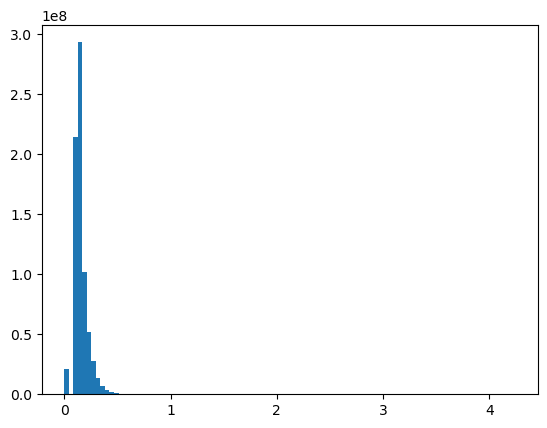

In [8]:
import h5py
import os
data_dir = '/home/qezlou/projects/lae_detection/data/'
file_name = os.path.join(data_dir, 'fib_spec', 'all_calfibs.h5')
with h5py.File(file_name, 'r') as f:
    calfibe = f['calfibe'][:]
    plt.hist(calfibe.flatten(), bins=100)

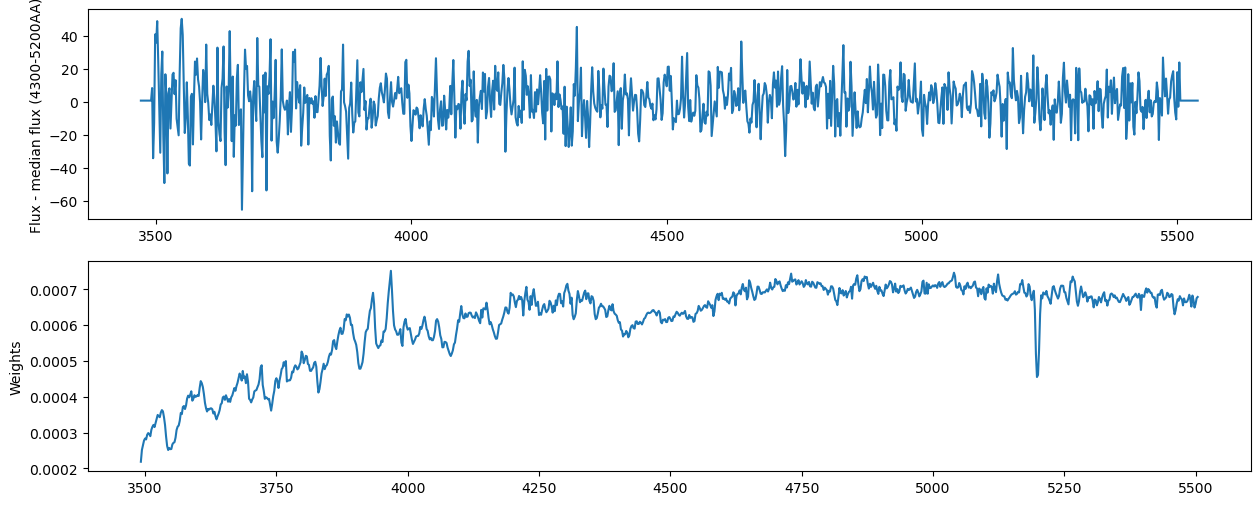

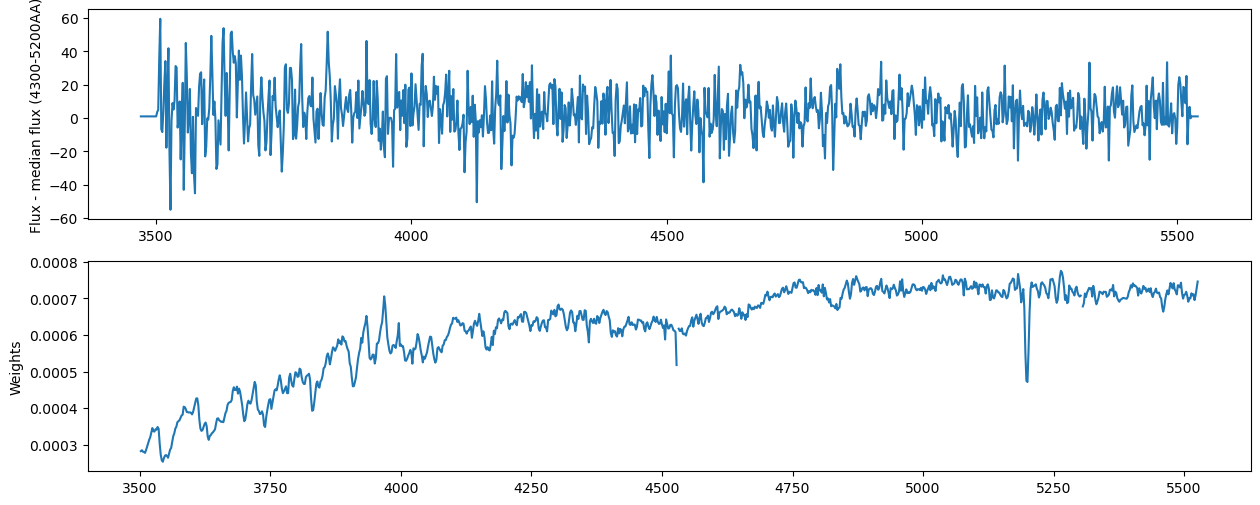

In [2]:
from matplotlib import pyplot as plt

for ind in [12, 64]:
    fig, ax = plt.subplots(2,1, figsize=(15,6))
    ax[0].plot(instrument._wave_obs.numpy(), spec[ind].numpy())
    ax[0].set_ylabel('Flux - median flux (4300-5200AA)')
    ax[1].plot(instrument._wave_obs.numpy(), w[ind].numpy())
    ax[1].set_ylabel('Weights')

In [3]:
import h5py
with h5py.File('/home/qezlou/projects/lae_detection/data/fib_spec/all_calfibs.h5','r') as f:
    print(f['calfib'].shape)  # Should print (569, 2225)

(712522, 1036)


2225*